# Exploratory Data Analysis

## Food Price Volatility & Market Risk Prediction

This notebook explores the cleaned mandi price data for Tomato, Onion, and Potato from 2022 to 2026.

The analysis focuses on:
- Data coverage across years
- Commodity-wise price behavior
- Market and state distribution
- Price trends over time
- Price variability and potential volatility patterns


In [1]:
import pandas as pd

years = [2022, 2023, 2024, 2025, 2026]

dfs = []

for year in years:
    df = pd.read_csv(
        f"../data/processed/cleaned_{year}.csv"
    )
    
    df["Year"] = year
    dfs.append(df)

eda_df = pd.concat(
    dfs,
    ignore_index=True
)

print("Combined rows:", len(eda_df))
print("\nShape:", eda_df.shape)

print("\nYear-wise rows:")
print(eda_df["Year"].value_counts().sort_index())

Combined rows: 2522952

Shape: (2522952, 12)

Year-wise rows:
Year
2022    591651
2023    576161
2024    661443
2025    635761
2026     57936
Name: count, dtype: int64


In [2]:
print("Columns:")
print(eda_df.columns.tolist())

print("\nData types:")
print(eda_df.dtypes)

Columns:
['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade', 'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price', 'Commodity_Code', 'Year']

Data types:
State                 str
District              str
Market                str
Commodity             str
Variety               str
Grade                 str
Arrival_Date          str
Min_Price         float64
Max_Price         float64
Modal_Price       float64
Commodity_Code      int64
Year                int64
dtype: object


In [3]:
eda_df["Arrival_Date"] = pd.to_datetime(
    eda_df["Arrival_Date"],
    errors="coerce"
)

print(eda_df["Arrival_Date"].dtype)

print("\nInvalid dates:", eda_df["Arrival_Date"].isna().sum())

print("\nDate range:")
print("Start:", eda_df["Arrival_Date"].min())
print("End:", eda_df["Arrival_Date"].max())

datetime64[us]

Invalid dates: 0

Date range:
Start: 2022-01-01 00:00:00
End: 2026-04-20 00:00:00


In [4]:
missing_values = eda_df.isna().sum()

print(missing_values)

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
Year              0
dtype: int64


In [5]:
commodity_counts = (
    eda_df["Commodity"]
    .value_counts()
    .sort_index()
)

print(commodity_counts)

Commodity
Onion     864245
Potato    844710
Tomato    813997
Name: count, dtype: int64


In [6]:
year_commodity_counts = pd.crosstab(
    eda_df["Year"],
    eda_df["Commodity"]
)

print(year_commodity_counts)

Commodity   Onion  Potato  Tomato
Year                             
2022       201558  201392  188701
2023       196176  198908  181077
2024       225151  221563  214729
2025       220857  204044  210860
2026        20503   18803   18630


In [7]:
price_stats = (
    eda_df
    .groupby("Commodity")["Modal_Price"]
    .describe()
)

print(price_stats)


              count         mean            std    min     25%     50%  \
Commodity                                                                
Onion      864245.0  3453.587796  987027.449559  0.115  1370.0  2000.0   
Potato     844710.0  1803.091440    1422.054764  0.160  1000.0  1400.0   
Tomato     813997.0  2391.537235    1953.882444  0.320  1200.0  2000.0   

              75%          max  
Commodity                       
Onion      3000.0  917588483.0  
Potato     2200.0      77000.0  
Tomato     3000.0     404000.0  


In [8]:
extreme_prices = (
    eda_df[
        ["Arrival_Date", "State", "District", "Market",
         "Commodity", "Variety", "Min_Price",
         "Max_Price", "Modal_Price"]
    ]
    .sort_values("Modal_Price", ascending=False)
    .head(20)
)

print(extreme_prices.to_string(index=False))

Arrival_Date          State         District                        Market Commodity Variety   Min_Price   Max_Price  Modal_Price
  2024-12-23    Maharashtra           Nashik                        Kalvan     Onion     Red 917588483.0 917588483.0  917588483.0
  2023-11-09          Bihar        Jehanabad                     Jehanabad     Onion   White    420000.0    480000.0     460000.0
  2024-08-07     Tamil Nadu     Chengalpattu Chengalpet (Uzhavar Sandhai )    Tomato   Deshi      3500.0    404000.0     404000.0
  2024-09-06     Tamil Nadu  Thiruvannamalai      Arani (Uzhavar Sandhai )    Tomato   Deshi      2500.0    353000.0     353000.0
  2023-12-19          Bihar        Jehanabad                     Jehanabad     Onion   White    350000.0    400000.0     350000.0
  2025-02-21          Bihar        Jehanabad                     Jehanabad     Onion   White    250000.0    300000.0     300000.0
  2025-02-18          Bihar        Jehanabad                     Jehanabad     Onion   Whi

In [9]:
print("\nCommodity-wise extreme prices (> ₹10,000):")

print(
    eda_df[eda_df["Modal_Price"] > 10000]
    .groupby("Commodity")
    .size()
)


Commodity-wise extreme prices (> ₹10,000):
Commodity
Onion     1293
Potato     955
Tomato    3379
dtype: int64


In [10]:
extreme_by_year = (
    eda_df[eda_df["Modal_Price"] > 10000]
    .groupby("Year")
    .size()
)

print(extreme_by_year)

Year
2022     784
2023    3488
2024    1002
2025     345
2026       8
dtype: int64


In [11]:
extreme_2023 = (
    eda_df[
        (eda_df["Year"] == 2023) &
        (eda_df["Modal_Price"] > 10000)
    ]
    .groupby("Commodity")
    .size()
)

print(extreme_2023)

Commodity
Onion      420
Potato     385
Tomato    2683
dtype: int64


In [12]:
tomato_extreme_2023 = (
    eda_df[
        (eda_df["Year"] == 2023) &
        (eda_df["Commodity"] == "Tomato") &
        (eda_df["Modal_Price"] > 10000)
    ]
)

print(
    tomato_extreme_2023["Market"]
    .value_counts()
    .head(15)
)

Market
Pothencode              207
Jalukie                  73
Kollengode               70
Madanapalli              46
Alipurduar               36
Bishalgarh               35
Kamakhyanagar            35
Karsiyang (Matigara)     35
Saharpada                35
Keonjhar                 31
Car Nicobar              30
Kollam                   30
Keonjhar (Dhekikote)     30
Khatra                   29
Vankaner (Sub yard)      26
Name: count, dtype: int64


In [13]:
pothencode_prices = (
    eda_df[
        (eda_df["Year"] == 2023) &
        (eda_df["Commodity"] == "Tomato") &
        (eda_df["Market"] == "Pothencode")
    ]["Modal_Price"]
)

print(pothencode_prices.describe())

count      220.000000
mean     19441.363636
std       9481.611473
min       4540.000000
25%      13540.000000
50%      16990.000000
75%      22915.000000
max      60040.000000
Name: Modal_Price, dtype: float64


In [15]:
market_median = (
    eda_df
    .groupby(["Commodity", "Market"])["Modal_Price"]
    .median()
    .rename("Market_Median_Price")
)

eda_df = eda_df.merge(
    market_median,
    on=["Commodity", "Market"],
    how="left"
)

print(
    eda_df[
        ["Commodity", "Market", "Modal_Price", "Market_Median_Price"]
    ].head()
)

  Commodity           Market  Modal_Price  Market_Median_Price
0    Tomato  Mulakalacheruvu       3500.0               1400.0
1    Potato        Palamaner       1600.0               1600.0
2    Tomato        Palamaner       2500.0               1650.0
3    Tomato         Punganur       2470.0               1410.0
4    Tomato       Vayalapadu       3360.0               1480.0


In [16]:
eda_df["Price_to_Market_Median"] = (
    eda_df["Modal_Price"] /
    eda_df["Market_Median_Price"]
)

market_relative_extremes = (
    eda_df[
        eda_df["Market_Median_Price"] > 0
    ]
    .sort_values(
        "Price_to_Market_Median",
        ascending=False
    )
    [
        [
            "Arrival_Date",
            "Commodity",
            "Market",
            "Modal_Price",
            "Market_Median_Price",
            "Price_to_Market_Median"
        ]
    ]
    .head(20)
)

print(market_relative_extremes.to_string(index=False))

Arrival_Date Commodity                           Market  Modal_Price  Market_Median_Price  Price_to_Market_Median
  2024-12-23     Onion                           Kalvan  917588483.0              1300.00           705837.294615
  2026-01-04    Tomato Pavilion Ground,Khammam,RBZ APMC       3800.0                 0.48             7916.666667
  2026-04-05    Tomato  Sattupalli (ramalayam),RBZ APMC       2000.0                 0.48             4166.666667
  2023-11-09     Onion                        Jehanabad     460000.0              2200.00              209.090909
  2024-07-16    Potato                     Virudhunagar       9600.0                56.00              171.428571
  2024-07-09    Potato                     Virudhunagar       9600.0                56.00              171.428571
  2024-07-12    Potato                     Virudhunagar       9600.0                56.00              171.428571
  2024-07-10    Potato                     Virudhunagar       9200.0                56.0

In [17]:
kalvan_onion = (
    eda_df[
        (eda_df["Commodity"] == "Onion") &
        (eda_df["Market"] == "Kalvan") &
        (eda_df["Arrival_Date"].between(
            "2024-12-15",
            "2024-12-31"
        ))
    ]
    [
        [
            "Arrival_Date",
            "Min_Price",
            "Max_Price",
            "Modal_Price"
        ]
    ]
    .sort_values("Arrival_Date")
)

print(kalvan_onion.to_string(index=False))

Arrival_Date   Min_Price   Max_Price  Modal_Price
  2024-12-16      1500.0      2905.0       2100.0
  2024-12-17       700.0      2855.0       1900.0
  2024-12-19       700.0      2705.0       1800.0
  2024-12-20       900.0      2760.0       1850.0
  2024-12-23 917588483.0 917588483.0  917588483.0
  2024-12-24       500.0      2255.0       1601.0
  2024-12-27       750.0      2651.0       1700.0
  2024-12-28       800.0      2705.0       1805.0
  2024-12-30      1300.0      2930.0       2210.0


In [18]:
eda_df = eda_df.sort_values(
    ["Commodity", "Market", "Arrival_Date"]
).copy()

eda_df["Previous_Modal_Price"] = (
    eda_df
    .groupby(["Commodity", "Market"])["Modal_Price"]
    .shift(1)
)

eda_df["Price_Ratio_From_Previous"] = (
    eda_df["Modal_Price"] /
    eda_df["Previous_Modal_Price"]
)

print(
    eda_df[
        eda_df["Price_Ratio_From_Previous"] > 20
    ][
        [
            "Arrival_Date",
            "Commodity",
            "Market",
            "Previous_Modal_Price",
            "Modal_Price",
            "Price_Ratio_From_Previous"
        ]
    ]
    .sort_values(
        "Price_Ratio_From_Previous",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

Arrival_Date Commodity                           Market  Previous_Modal_Price  Modal_Price  Price_Ratio_From_Previous
  2024-12-23     Onion                           Kalvan              1850.000  917588483.0              495993.774595
  2025-12-24    Potato                      Mapusa APMC                 0.160       1650.0               10312.500000
  2026-02-08    Potato                   Kalimpong APMC                 0.260       2600.0               10000.000000
  2025-12-23     Onion                      Mapusa APMC                 0.175       1600.0                9142.857143
  2026-01-04    Tomato Pavilion Ground,Khammam,RBZ APMC                 0.520       3800.0                7307.692308
  2026-04-05    Tomato  Sattupalli (ramalayam),RBZ APMC                 0.480       2000.0                4166.666667
  2025-12-10     Onion                      Mapusa APMC                 0.115        130.0                1130.434783
  2022-10-15     Onion             Junnar (Narayangaon) 

In [19]:
low_price = eda_df[
    eda_df["Modal_Price"] < 100
]

print("Modal_Price < ₹100:", len(low_price))

print("\nBy year:")
print(low_price.groupby("Year").size())

print("\nBy commodity:")
print(low_price.groupby("Commodity").size())

Modal_Price < ₹100: 5310

By year:
Year
2022       1
2023      46
2024    5143
2025      59
2026      61
dtype: int64

By commodity:
Commodity
Onion     1867
Potato    1619
Tomato    1824
dtype: int64


In [20]:
low_2024_market = (
    eda_df[
        (eda_df["Year"] == 2024) &
        (eda_df["Modal_Price"] < 100)
    ]
    .groupby(["Commodity", "Market"])
    .size()
    .sort_values(ascending=False)
)

print(low_2024_market.head(20))

Commodity  Market           
Onion      Kochas (Balthari)    50
Tomato     Virudhunagar         20
Onion      Arani                20
           Ambasamudram         20
           Arcot                20
           Ariyalur Market      20
           Attur                20
Tomato     Vellore              20
           Thenkasi             20
           Theni                20
           Thanjavur            20
           Thammampati          20
           Thalavadi            20
           Sulur                20
           Sivagangai           20
           Sirkali              20
           Singampuneri         20
           Sathyamangalam       20
           Sathur               20
Onion      Aranthangi           20
dtype: int64


In [21]:
kochas_onion = (
    eda_df[
        (eda_df["Year"] == 2024) &
        (eda_df["Commodity"] == "Onion") &
        (eda_df["Market"] == "Kochas (Balthari)")
    ]
    [
        [
            "Arrival_Date",
            "Min_Price",
            "Max_Price",
            "Modal_Price"
        ]
    ]
    .sort_values("Arrival_Date")
)

print(kochas_onion.to_string(index=False))


Arrival_Date  Min_Price  Max_Price  Modal_Price
  2024-02-20       16.0       18.0         17.0
  2024-02-22       16.0       18.0         17.0
  2024-02-23       15.0       17.0         16.0
  2024-02-24       14.0       16.0         15.0
  2024-02-27       15.0       17.0         16.0
  2024-02-28       15.0       17.0         16.0
  2024-02-29       16.0       18.0         17.0
  2024-03-01       14.0       16.0         15.0
  2024-03-04       16.0       18.0         17.0
  2024-03-05       14.0       16.0         15.0
  2024-03-06       14.0       16.0         15.0
  2024-03-07       16.0       18.0         17.0
  2024-03-09       16.0       18.0         17.0
  2024-03-11       16.0       18.0         17.0
  2024-03-12       15.0       17.0         16.0
  2024-03-13       16.0       18.0         17.0
  2024-03-14       17.0       19.0         18.0
  2024-03-15       16.0       18.0         17.0
  2024-03-16       18.0       20.0         19.0
  2024-03-18       16.0       18.0      

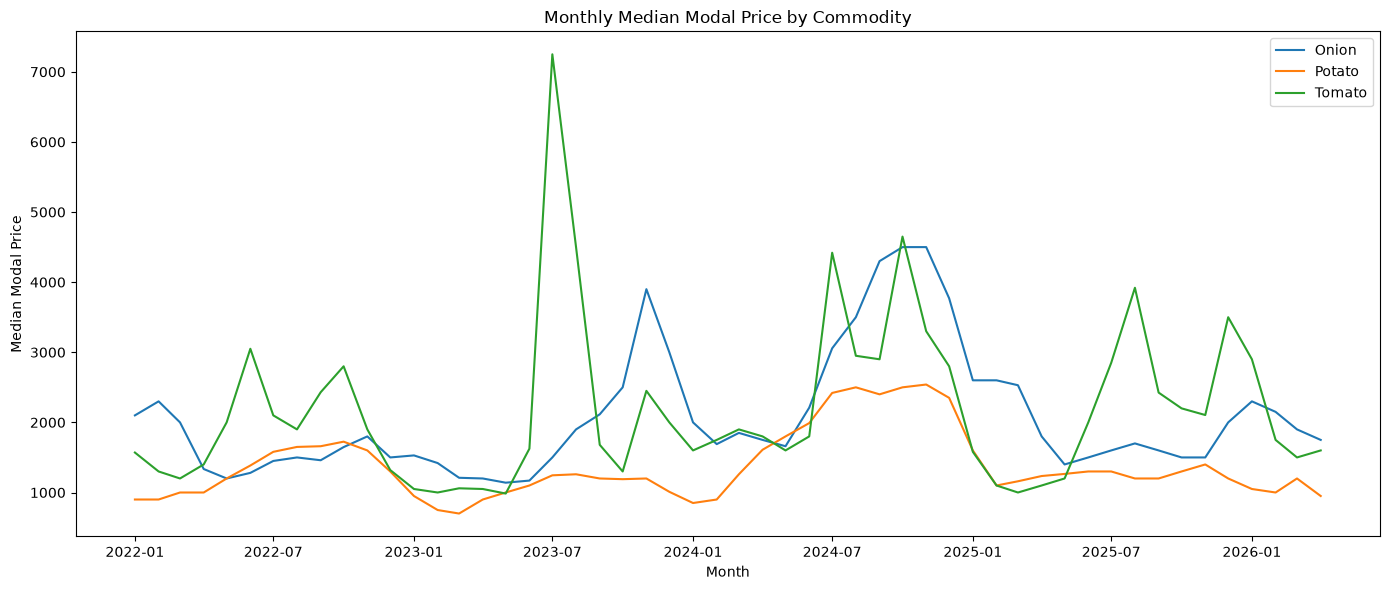

In [26]:
import matplotlib.pyplot as plt

monthly_price = (
    eda_df
    .assign(Month=eda_df["Arrival_Date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["Month", "Commodity"])["Modal_Price"]
    .median()
    .reset_index()
)

plt.figure(figsize=(14, 6))

for commodity in monthly_price["Commodity"].unique():
    data = monthly_price[monthly_price["Commodity"] == commodity]
    plt.plot(
        data["Month"],
        data["Modal_Price"],
        label=commodity
    )

plt.title("Monthly Median Modal Price by Commodity")
plt.xlabel("Month")
plt.ylabel("Median Modal Price")
plt.legend()
plt.xticks(rotation=00)
plt.tight_layout()
plt.show()

## EDA Summary

- The combined cleaned dataset contains records from 2022 to 2026 for Onion, Potato, and Tomato.
- The 2026 data covers only part of the year and is therefore not directly comparable with the complete years 2022–2025.
- Modal Price shows substantial variation across commodities, markets, and time periods.
- Extreme price observations were identified, including isolated unusually large values.
- Very low prices were also observed in some markets; market-level inspection showed that some low-price sequences were systematic rather than isolated invalid records.
- Therefore, a simple global price threshold was not used to remove all low-price observations.
- Monthly median price trends show that food commodity prices vary considerably over time, supporting the need for a volatility-focused prediction task.
- The cleaned data is now ready for target construction and time-aware feature engineering.